<a href="https://colab.research.google.com/github/aldrinjohny-ai/ml_lab/blob/main/exp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error,r2_score

In [3]:
housing=fetch_california_housing()

In [17]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target
X = df[['AveRooms']].values
y = df['MedHouseVal'].values

In [9]:
X=(X-X.mean())/X.std()

In [15]:
X_b = np.c_[np.ones(X.shape[0]),X] #add bias terms
theta=np.random.randn(2,1)#initlaize parameters
#hyperparameters
learning_rate=0.01
n_iterations=1000
m=len(y)

#reshape y
y=y.reshape(-1,1)

#gradient Descent loop
for iteration in range(n_iterations):
  gradients=(2/m)*X_b.T.dot(X_b.dot(theta)-y)
  theta=theta-learning_rate*gradients

print("Theta from Gradient Descent:",theta)

Theta from Gradient Descent: [[2.06855817]
 [0.17533742]]


In [18]:
#normal Equations solutions
theta_normal=np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
print("Theta from Normal Equations:",theta_normal)

Theta from Normal Equations: [2.06855817 0.17533742]


In [21]:
#predictions\
y_pred_gd=X_b.dot(theta)
y_pred_normal=X_b.dot(theta_normal)

#metrices
mse_gd=mean_squared_error(y,y_pred_gd)
r2_gd=r2_score(y,y_pred_gd)
mse_ne=mean_squared_error(y,y_pred_normal)
r2_ne=r2_score(y,y_pred_normal)

print("gradient descent -> MSE",mse_gd,"R2",r2_gd)
print("normal equations -> MSE",mse_ne,"R2",r2_ne)

gradient descent -> MSE 1.3008070902505422 R2 0.023088282755354128
normal equations -> MSE 1.3008070902505422 R2 0.023088282755354128


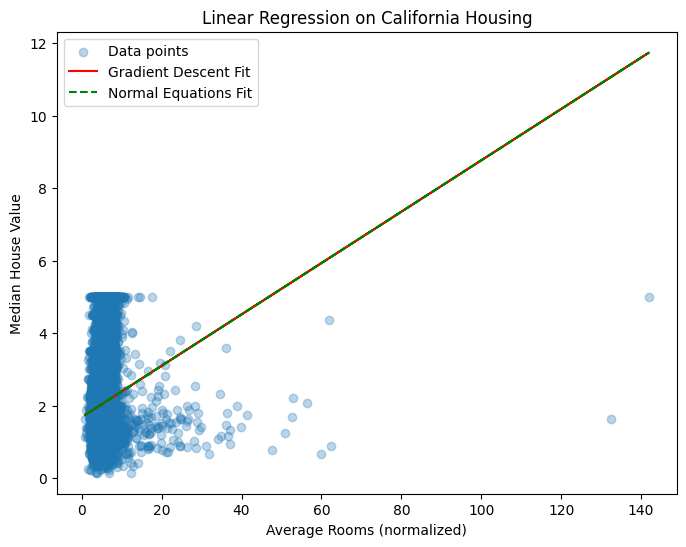

In [24]:
#visualisation
plt.figure(figsize=(8,6))
plt.scatter(X,y,alpha=0.3,label="Data points")
plt.plot(X,y_pred_gd,color='red',label="Gradient Descent Fit")
plt.plot(X,y_pred_normal,color='green',linestyle="--",label="Normal Equations Fit")
plt.xlabel("Average Rooms (normalized)")
plt.ylabel("Median House Value")
plt.legend()
plt.title("Linear Regression on California Housing")
plt.show()